# 216. Combination Sum III
https://leetcode.com/problems/combination-sum-iii/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Backtracking | $O(\binom{9}{k})$ | $O(k)$ | Optimal — prune early |
| Bitmask enumeration | $O(2^9)$ | $O(k)$ | Enumerate all subsets of {1..9} |

## Methodology

Use backtracking to find all combinations of k numbers from 1-9 that sum to n. Start from digit 1, pick a digit, recurse with remaining sum and count, then backtrack. Prune when remaining sum goes negative or when we cannot fill the required count with remaining digits.

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> CombinationSum3(int k, int n) {
        var result = new List<IList<int>>();
        Backtrack(result, new List<int>(), k, n, 1);
        return result;
    }

    private void Backtrack(List<IList<int>> result, List<int> curr, int k, int remain, int start) {
        if (curr.Count == k) {
            if (remain == 0)
                result.Add(new List<int>(curr));
            return;
        }
        for (int i = start; i <= 9; i++) {
            if (i > remain) break;
            curr.Add(i);
            Backtrack(result, curr, k, remain - i, i + 1);
            curr.RemoveAt(curr.Count - 1);
        }
    }
}

### Python

In [ ]:
class Solution:
    def combinationSum3(self, k: int, n: int) -> list[list[int]]:
        result = []

        def backtrack(start: int, remain: int, curr: list[int]):
            if len(curr) == k:
                if remain == 0:
                    result.append(curr[:])
                return
            for i in range(start, 10):
                if i > remain:
                    break
                curr.append(i)
                backtrack(i + 1, remain - i, curr)
                curr.pop()

        backtrack(1, n, [])
        return result

### Go

In [ ]:
func combinationSum3(k int, n int) [][]int {
    var result [][]int
    var backtrack func(start, remain int, curr []int)
    backtrack = func(start, remain int, curr []int) {
        if len(curr) == k {
            if remain == 0 {
                tmp := make([]int, len(curr))
                copy(tmp, curr)
                result = append(result, tmp)
            }
            return
        }
        for i := start; i <= 9; i++ {
            if i > remain {
                break
            }
            backtrack(i+1, remain-i, append(curr, i))
        }
    }
    backtrack(1, n, nil)
    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn combination_sum3(k: i32, n: i32) -> Vec<Vec<i32>> {
        let mut result = Vec::new();
        Self::backtrack(&mut result, &mut Vec::new(), k, n, 1);
        result
    }

    fn backtrack(result: &mut Vec<Vec<i32>>, curr: &mut Vec<i32>, k: i32, remain: i32, start: i32) {
        if curr.len() as i32 == k {
            if remain == 0 {
                result.push(curr.clone());
            }
            return;
        }
        for i in start..=9 {
            if i > remain {
                break;
            }
            curr.push(i);
            Self::backtrack(result, curr, k, remain - i, i + 1);
            curr.pop();
        }
    }
}

## Example Scenarios

### 1. Common Case — Single Valid Combination
**Input:** `k = 3, n = 7`

Find 3 numbers from {1..9} summing to 7. Start with 1: need 2 more summing to 6. Pick 2: need 1 more summing to 4. Pick 4: sum is 7. Found [1,2,4]. No other valid combination exists.

WHY it's tricky: It isn't — validates basic backtracking finds the unique solution.

$C(9,3) = 84 \text{ possible combinations. Only 1 sums to 7. Pruning eliminates most early.}$

### 2. Slightly Complex — Multiple Valid Combinations
**Input:** `k = 3, n = 15`

Multiple solutions: [1,5,9], [1,6,8], [2,4,9], [2,5,8], [2,6,7], [3,4,8], [3,5,7], [4,5,6]. Eight valid combinations. Pruning (i > remain → break) cuts branches where a digit alone exceeds the remaining target.

WHY it's tricky: With 8 valid combinations, the search tree has many valid leaves. Pruning reduces exploration from 84 to ~30 nodes.

$C(9,3) = 84 \text{ total. } 8 \text{ valid} \approx 9.5\%. \text{ Pruning visits} \sim 30 \text{ nodes.}$

### 3. Edge Case: Time Factor — k = 5, Maximal Search Tree
**Input:** `k = 5, n = 25`

$C(9,5) = 126$ possible 5-element subsets — the maximum among all C(9,k). The sum 25 is near the middle of the range [min=15, max=35], maximizing the number of valid solutions.

WHY it's tricky: C(9,5) = 126 is the peak of C(9,k). With n near the middle of the feasible range, pruning is least effective. But 126 × O(5) = O(630) — still tiny.

$C(9,5) = 126. \text{ Max explorations: } 126 \times O(5) = O(630)$

### 4. Edge Case: Space Factor — k = 9, Deepest Recursion
**Input:** `k = 9, n = 45`

The only 9-element subset of {1..9} is {1,2,...,9} with sum 45. Recursion goes 9 levels deep. This is maximum stack depth and combination size.

WHY it's tricky: k = 9 means using ALL digits 1-9. There is exactly one such subset, and its sum must be 45 (= 1+2+...+9). Any other n with k = 9 returns []. Max recursion depth = 9.

$C(9,9) = 1. \text{ Stack depth} = k = 9. \text{ Space} = O(k) = O(9)$

### 5. Almost-Impossible — Target Exceeds Maximum Possible Sum
**Input:** `k = 2, n = 18`

Maximum sum of 2 digits from {1..9} is 8+9 = 17. Since n = 18 > 17, no valid combination exists. An early feasibility check (n > sum of k largest digits) can short-circuit the entire search.

WHY it's tricky: Without an early exit, backtracking wastes time on branches that can never succeed. Also, n < sum of k smallest digits ($n < k(k+1)/2$) is another early exit.

$\text{Max sum for } k=2: 8+9 = 17 < 18 = n. \text{ Valid range: } n \in [3, 17]$


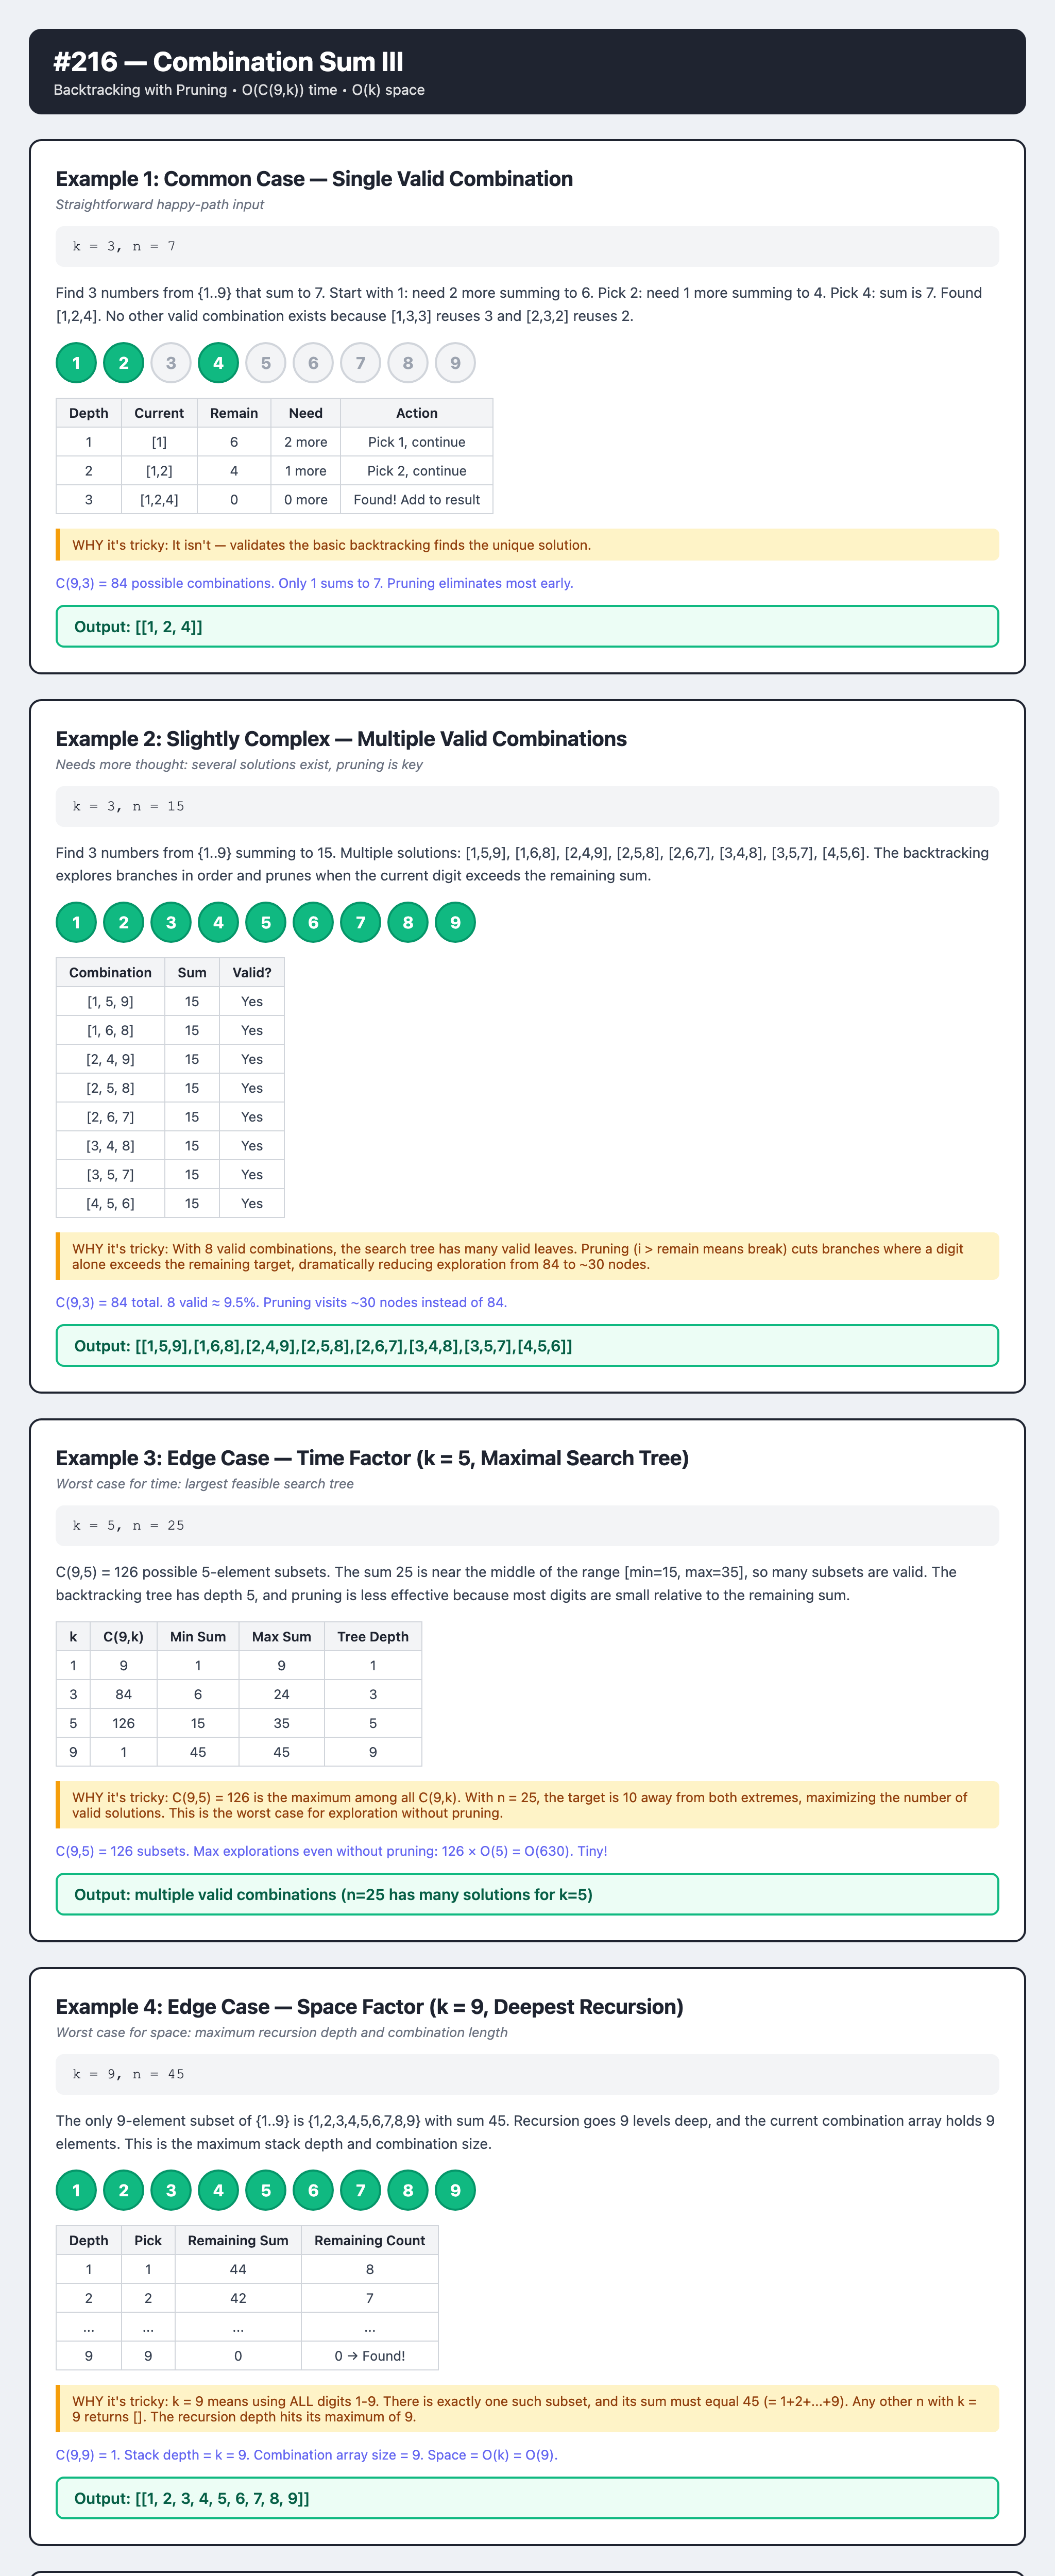